# AutoMorph on three shapes, biomarker by biomarker

A close reading of one implementation. The
[main notebook](../biomarker-synthetic.ipynb) compares six programs across nine shapes and answers
*which of these agree*; this one asks a narrower question about
[AutoMorph](../../docs/projects/automorph.md) alone — **what does it actually return, on the three
simplest shapes, at each angle, beside what the geometry requires?**

Everything is under **AutoMorph's own column names**, not the catalogued ones. That is the point:
the catalogued names exist to make two programs comparable, and there is only one program here, so
the names its authors chose are the ones a reader checking against their documentation will look
for. Where a column maps onto a catalogued biomarker the mapping is shown beside it, and where the
shape settles a theoretical value that is shown too.

**The three shapes, in order of how much they ask for:**

| Shape | What it is | Why it comes first |
| --- | --- | --- |
| `straight` | one straight vessel per class, leaving the optic disc | every curvature measure must read zero and every tortuosity exactly 1 |
| `arc` | a circular arc per class | curvature is exactly 1/r, and the arc-to-chord ratio has a closed form |
| `sinusoid` | a sine wave per class | the only one of the three whose curvature changes sign |

A blank in the theory column means **this shape settles no value for that quantity** — which is not
the same as the quantity being wrong, and not the same as AutoMorph declining to answer it.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))

from benchmarks import biomarker_synthetic as benchmark  # noqa: E402
from benchmarks.shapes import store  # noqa: E402
from biomarkers import canonical  # noqa: E402
from biomarkers.utils import catalogue  # noqa: E402

#: The one implementation this notebook reads. Change it and everything below follows.
IMPLEMENTATION = "automorph"

#: In order of how much they ask for: a straight vessel, then a curve, then a curve that changes
#: its mind about which way it bends.
SHAPES = ("straight", "arc", "sinusoid")

EVIDENCE = ROOT / "results" / benchmark.NAME / IMPLEMENTATION
STORE = ROOT / store.STORE
pd.set_option("display.width", 200, "display.max_rows", 200)

#: AutoMorph's own column name → the catalogued biomarker it answers to, or None where the
#: catalogue has no name for it. This is the adapter's claim, not the run's.
NAMES = catalogue.load(IMPLEMENTATION).declare()["names"]

TRUTH = pd.read_csv(STORE / "ground_truth.csv").set_index("key")

#: How many microns a pixel is worth, read from the manifest rather than assumed.
UM_PER_PX = float(pd.DataFrame(store.read(STORE))["um_per_px"].iloc[0])
print(f"{IMPLEMENTATION}: {len(NAMES)} columns, "
      f"{sum(1 for v in NAMES.values() if v)} of them with a catalogued name")

automorph: 18 columns, 15 of them with a catalogued name


### The three shapes, at the four angles

Each row is one shape and each column one angle. **They are not rotations of a picture** — every
panel is drawn afresh from the same equations with the angle as a parameter, so the geometry in a
row is identical across it and only the pixel lattice underneath has moved. That is what makes a
number changing along a row a statement about the software rather than about the eye.

Artery in red, vein in blue, the optic disc and the two rings the central retinal equivalents are
measured over drawn in outline. The vessels leave the disc, which is why the shapes sit off to one
side rather than in the middle.

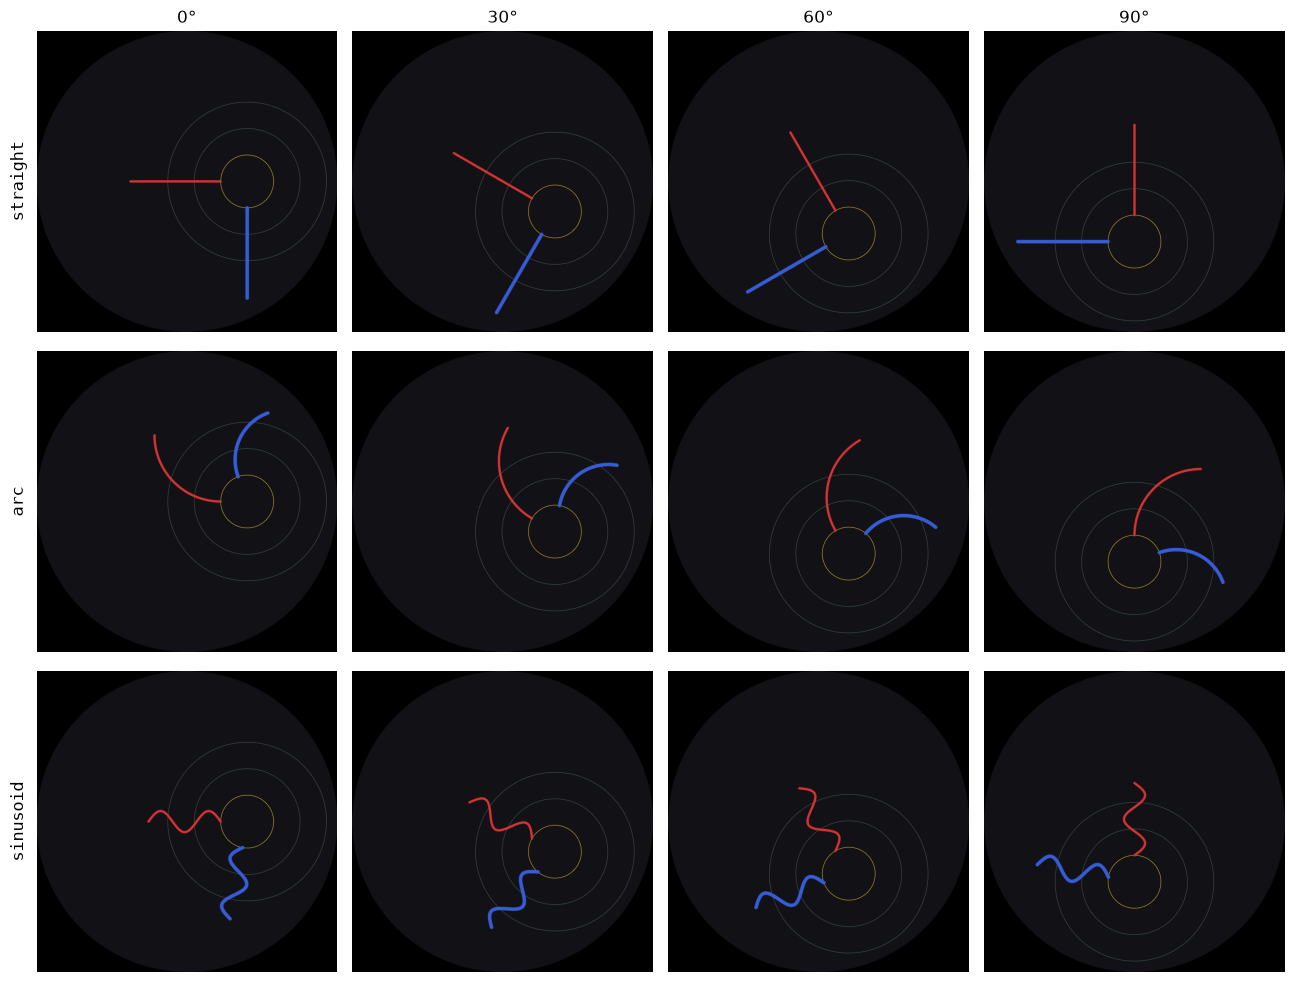

In [2]:
import matplotlib.pyplot as plt

from benchmarks.shapes import library  # noqa: E402

ANGLES = (0, 30, 60, 90)
figure, panels = plt.subplots(len(SHAPES), len(ANGLES), figsize=(13, 10))
for row, shape in enumerate(SHAPES):
    for column, angle in enumerate(ANGLES):
        rendering = store.load(STORE, store.key_of(shape, benchmark.SIDE, angle))
        panels[row, column].imshow(library.demo_image(rendering))
        panels[row, column].set_axis_off()
        if row == 0:
            panels[row, column].set_title(f"{angle}°", fontsize=12)
    panels[row, 0].text(
        -0.06, 0.5, shape, transform=panels[row, 0].transAxes,
        rotation=90, va="center", ha="center", fontsize=12, family="monospace",
    )
figure.tight_layout()
plt.show()

In [3]:
def readings(shape: str) -> pd.DataFrame:
    """What AutoMorph returned for one shape: a row per column, a column per angle.

    The theoretical value is joined on last and only where the shape settles one, so a blank there
    is a statement about the fixture rather than about the implementation.

    **Every number in a row is in the implementation's own units, which are pixels.** A catalogued
    biomarker is in microns, so the theory is converted *back* onto the pixel grid before it is put
    beside figures this program actually printed — the point of this notebook being to read those
    figures as their authors would. The `unit` column says what the catalogued name is in, and
    `docs/benchmarks/biomarker-synthetic-results.md` is where the two meet the other way round.
    """
    measured = pd.read_csv(EVIDENCE / f"{shape}.csv")
    rows = {}
    for own in NAMES:
        values = {}
        for _, rendering in measured.iterrows():
            values[f"{rendering['rotation']:.0f}°"] = rendering.get(f"said_{own}")
        catalogued = NAMES[own]
        truth, unit = np.nan, ""
        if catalogued:
            unit = canonical.unit(catalogued)
            keys = [k for k in TRUTH.index if k.startswith(f"{shape}-")]
            if keys and catalogued in TRUTH.columns:
                # Back onto the pixel grid: the inverse of the one conversion this repository makes.
                truth = canonical.from_pixels(
                    catalogued, TRUTH.loc[keys[0], catalogued], 1.0 / UM_PER_PX
                )
        rows[own] = {
            **values,
            "theory, in px": truth,
            "catalogued as": catalogued or "—",
            "unit": unit or "—",
        }
    frame = pd.DataFrame(rows).T
    frame.index.name = f"{IMPLEMENTATION}'s own name"
    return frame


def show(shape: str) -> pd.DataFrame:
    frame = readings(shape)
    angles = [c for c in frame.columns if c.endswith("°")]
    numeric = frame[angles + ["theory, in px"]].astype(float)
    spread = numeric[angles].max(axis=1) - numeric[angles].min(axis=1)
    out = numeric.round(4)
    out["moves"] = spread.round(4)
    out["catalogued as"] = frame["catalogued as"]
    out["unit"] = frame["unit"]
    return out

## 1. `straight`

A single straight vessel per class, leaving the optic disc. **Everything about it is known
exactly**: the arc-to-chord ratio is 1, every curvature measure is 0, and the width is the width it
was drawn at. Nothing here is a hard measurement, which is what makes it the right place to start —
a value that is wrong on a straight line is wrong for a reason that has nothing to do with
difficulty.

In [4]:
show("straight")

,0°,30°,60°,90°,"theory, in px",moves,catalogued as,unit
automorph's own name,,,,,,,,
fractal_dimension_binary,0.9287,0.9671,1.0732,1.0010,NaN,0.1444,density/box-counting/vessels,1
vessel_density_binary,0.0057,0.0055,0.0055,0.0057,0.0060,0.0002,density/over-image/vessels,1
average_width_binary,15.2883,20.8782,21.0118,15.2983,20.0000,5.7235,calibre/width/vessels/length-weighted,µm
distance_tortuosity_binary,1.0015,0.0000,0.0000,1.0008,1.0000,1.0015,tortuosity/hart-tau1/vessels/mean,1
squared_curvature_tortuosity_binary,0.0356,0.0000,0.0000,0.0447,NaN,0.0447,—,—
tortuosity_density_binary,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,tortuosity/grisan-density/vessels/mean,1/µm
fractal_dimension_artery,0.9272,0.9766,0.9766,0.9272,NaN,0.0494,density/box-counting/artery,1
vessel_density_artery,0.0020,0.0021,0.0021,0.0020,0.0024,0.0001,density/over-image/artery,1
average_width_artery,17.4158,16.7509,16.8349,17.4490,16.0000,0.6981,calibre/width/artery/length-weighted,µm


## 2. `arc`

A circular arc per class, the two sharing a subtended angle and differing in radius. The
arc-to-chord ratio is `θ / (2 sin(θ/2))` in closed form and **independent of radius**, so both
classes must return the same tortuosity while their curvatures differ. That pairing is the test:
an implementation that returns different tortuosities for the two is measuring the radius somewhere
it should not.

In [5]:
show("arc")

,0°,30°,60°,90°,"theory, in px",moves,catalogued as,unit
automorph's own name,,,,,,,,
fractal_dimension_binary,1.0602,1.0652,0.9273,0.9788,NaN,0.1379,density/box-counting/vessels,1
vessel_density_binary,0.0054,0.0054,0.0054,0.0054,0.0059,0.0000,density/over-image/vessels,1
average_width_binary,19.3198,19.9532,20.2020,19.4914,19.4286,0.8821,calibre/width/vessels/length-weighted,µm
distance_tortuosity_binary,1.0447,1.0444,5.0928,3.3097,1.1107,4.0484,tortuosity/hart-tau1/vessels/mean,1
squared_curvature_tortuosity_binary,0.0535,0.0298,4.1918,12.4895,NaN,12.4597,—,—
tortuosity_density_binary,0.5278,0.4444,0.4722,0.8619,0.0000,0.4175,tortuosity/grisan-density/vessels/mean,1/µm
fractal_dimension_artery,0.9450,0.9690,0.9174,0.8983,NaN,0.0707,density/box-counting/artery,1
vessel_density_artery,0.0025,0.0025,0.0025,0.0025,0.0027,0.0000,density/over-image/artery,1
average_width_artery,15.3935,15.7666,16.2176,15.6527,16.0000,0.8241,calibre/width/artery/length-weighted,µm


## 3. `sinusoid`

A sine wave per class, and **the only one of the three whose curvature changes sign**. Its arc
length is an elliptic integral with no elementary closed form, so the theoretical value here is the
integral rather than a formula. It is the shape that settles the inflection count and Grisan's
density, both of which are zero on everything else.

In [6]:
show("sinusoid")

,0°,30°,60°,90°,"theory, in px",moves,catalogued as,unit
automorph's own name,,,,,,,,
fractal_dimension_binary,1.0693,0.9578,0.9999,1.1285,NaN,0.1707,density/box-counting/vessels,1
vessel_density_binary,0.0061,0.0061,0.0061,0.0061,0.0066,0.0001,density/over-image/vessels,1
average_width_binary,21.8694,20.1914,19.5547,22.6141,20.0000,3.0594,calibre/width/vessels/length-weighted,µm
distance_tortuosity_binary,0.0000,1.7075,1.0839,0.0000,1.3726,1.7075,tortuosity/hart-tau1/vessels/mean,1
squared_curvature_tortuosity_binary,0.0000,3.4469,0.1389,0.0000,NaN,3.4469,—,—
tortuosity_density_binary,0.0000,0.4468,0.1667,0.0000,0.0011,0.4468,tortuosity/grisan-density/vessels/mean,1/µm
fractal_dimension_artery,1.0015,0.9751,0.8174,1.0088,NaN,0.1914,density/box-counting/artery,1
vessel_density_artery,0.0024,0.0024,0.0024,0.0024,0.0026,0.0000,density/over-image/artery,1
average_width_artery,18.2489,15.6161,15.0731,18.9497,16.0000,3.8765,calibre/width/artery/length-weighted,µm


## 4. What the three tables show

Three things are readable straight off them, and none needs a statistic.

### 4.1 A tortuosity of zero is not a measurement

`distance_tortuosity` reads **exactly 0.0000** on `straight` at 30° and 60°, and on `sinusoid` at
0° and 90°. It is an arc length over a chord length, so its **minimum possible value is 1** — a
straight vessel scores 1 and nothing scores less. Zero is not a low reading; it is AutoMorph
failing and reporting the failure as a number.

That matters beyond this notebook. [PVBM raises](../biomarker-synthetic.ipynb) when it cannot measure,
which is recorded as an exception and excluded from every average. AutoMorph returns 0.0, which is
indistinguishable from a measurement in the stored evidence and **will be averaged into anybody's
table as though it were one**. A benchmark that only reported means would show this as AutoMorph
being unusually good at straight vessels.

### 4.2 The same vessel is two different widths depending on its angle

On `straight`, which is one unchanging vessel drawn at four angles:

| | 0° | 30° | 60° | 90° | drawn at |
| --- | --- | --- | --- | --- | --- |
| `average_width_vein` | **14.15** | 24.94 | 25.13 | **14.15** | 24 |
| `average_width_artery` | 17.42 | 16.75 | 16.83 | 17.45 | 16 |

The pattern is the same for both classes — the two **axis-aligned** angles disagree with the two
diagonal ones — and the size of it is not. The artery is out by about 9% either way; the vein reads
**41% narrow** at 0° and 90° and within 4% at 30° and 60°, an 11-pixel swing on a vessel that never
changed. Both are drawn the same way and differ only in being 16 and 24 pixels wide.

This notebook does not explain why. What it establishes is that the reading depends on the angle
the eye happened to sit at, which for a calibre measurement is the whole ballgame.

### 4.3 On a curve, the tortuosity moves by a factor of seven

On `arc`, where the geometry requires **1.111** at every angle and for both classes:

| | 0° | 30° | 60° | 90° | theory |
| --- | --- | --- | --- | --- | --- |
| `distance_tortuosity_vein` | 1.037 | 1.062 | **7.133** | **5.367** | 1.111 |
| `distance_tortuosity_artery` | 1.049 | 1.036 | 1.012 | **2.281** | 1.111 |

Two of the four vein readings are between five and seven times what the geometry requires. The arc
is drawn so that both classes share a subtended angle and differ only in radius, and the
arc-to-chord ratio does not depend on radius — so the two rows ought to be the same four numbers.
They are not.

### 4.4 What is not checked here

Roughly half of what AutoMorph returns carries no theory on these three shapes: every fractal
dimension, the artery and vein vessel densities, and `squared_curvature_tortuosity`, which has no
catalogued name at all. Those rows are reported and unchecked. **Unchecked is a third state** —
neither passed nor failed — and the blanks in the theory column are the honest way to say so.
